
Circuit Diagram:


Measurement Counts:

{'11000': 65, '10000': 140, '01010': 21, '10010': 74, '10100': 97, '11001': 19, '11100': 48, '01111': 4, '00100': 24, '00001': 21, '10110': 63, '00000': 40, '10101': 33, '00110': 15, '11110': 38, '11011': 14, '10001': 35, '10011': 24, '11111': 5, '01110': 9, '00011': 10, '00111': 9, '11010': 37, '11101': 13, '00010': 25, '01001': 11, '01100': 29, '01000': 29, '00101': 7, '10111': 28, '01011': 11, '01101': 2}


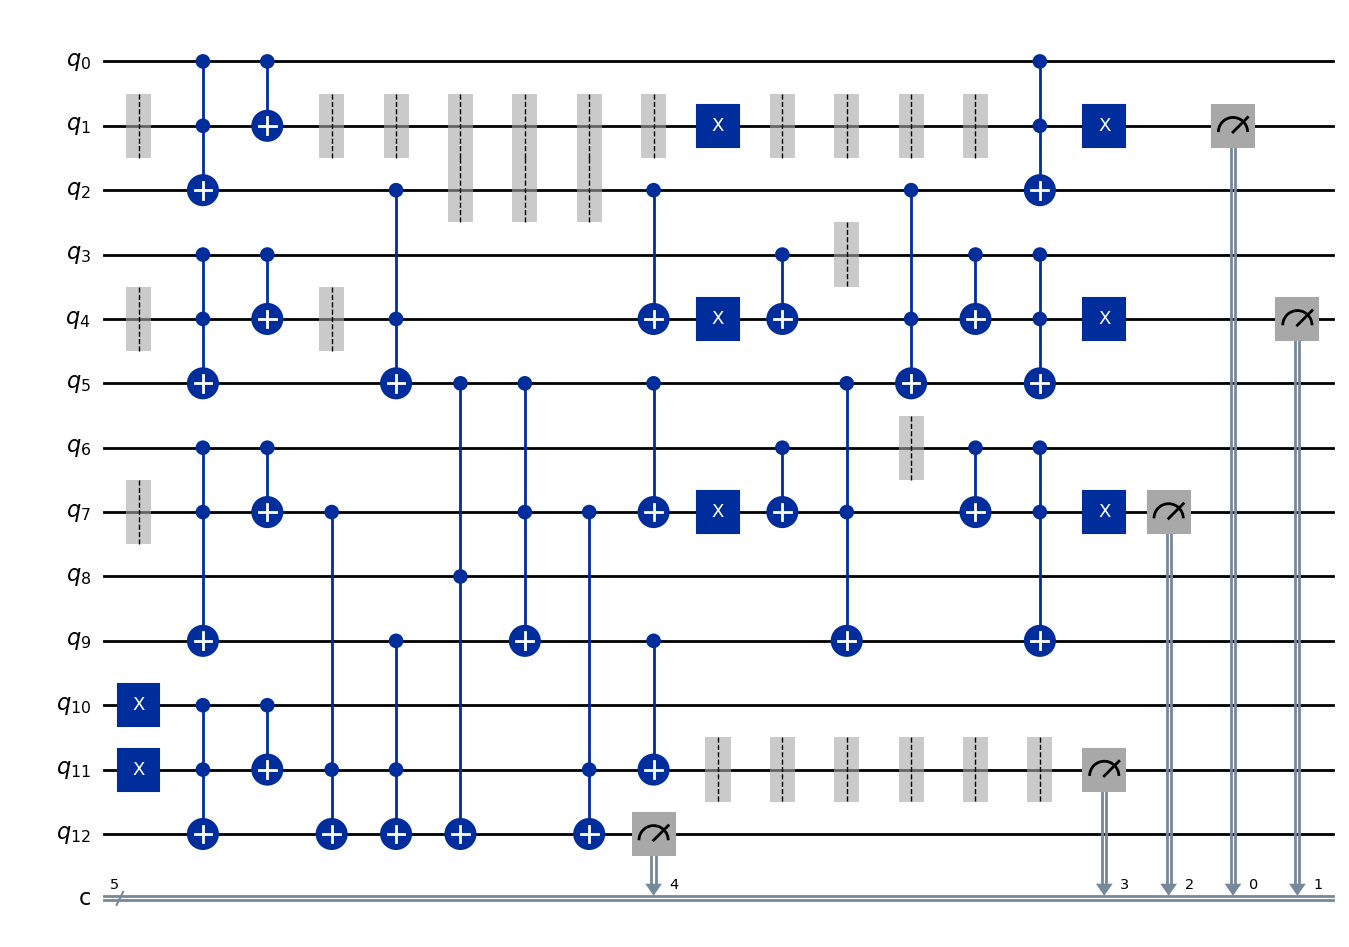

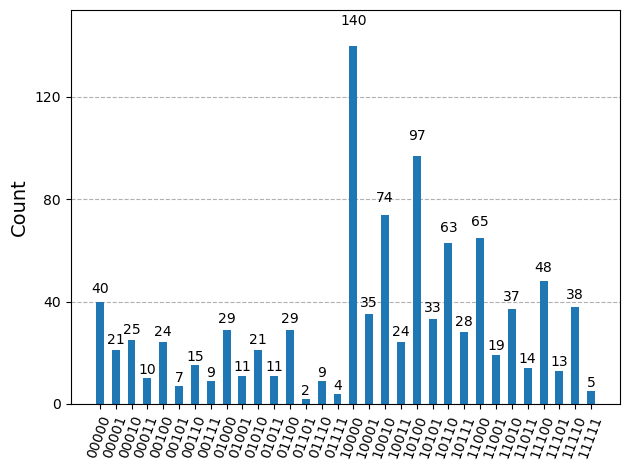


RESULTS

Correct Output: 10000

Correct Counts: 140

Error Rate (ER): 86.0

Mean Error Distance: 6.614

NMED: 0.21335483870967742

MRED: 0.413375

Success Rate: 0.14

Success Rate:
14.000000000000002


In [1]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# =====================================================
# 4-BIT Thapliyal ADDER
# TEST CASE:
# 1000 + 1000 = 10000
# =====================================================

from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from numpy import pi

qreg_q = QuantumRegister(13, 'q')
creg_c = ClassicalRegister(5, 'c')
circuit = QuantumCircuit(qreg_q, creg_c)

circuit.barrier(qreg_q[1])
circuit.barrier(qreg_q[4])
circuit.barrier(qreg_q[7])
circuit.x(qreg_q[10])
circuit.x(qreg_q[11])
circuit.ccx(qreg_q[0], qreg_q[1], qreg_q[2])
circuit.ccx(qreg_q[3], qreg_q[4], qreg_q[5])
circuit.ccx(qreg_q[6], qreg_q[7], qreg_q[9])
circuit.ccx(qreg_q[10], qreg_q[11], qreg_q[12])
circuit.cx(qreg_q[0], qreg_q[1])
circuit.cx(qreg_q[3], qreg_q[4])
circuit.cx(qreg_q[6], qreg_q[7])
circuit.cx(qreg_q[10], qreg_q[11])
circuit.barrier(qreg_q[4])
circuit.ccx(qreg_q[7], qreg_q[11], qreg_q[12])
circuit.barrier(qreg_q[1])
circuit.barrier(qreg_q[1])
circuit.ccx(qreg_q[2], qreg_q[4], qreg_q[5])
circuit.ccx(qreg_q[9], qreg_q[11], qreg_q[12])
circuit.barrier(qreg_q[1])
circuit.ccx(qreg_q[5], qreg_q[8], qreg_q[12])
circuit.barrier(qreg_q[2])
circuit.barrier(qreg_q[1])
circuit.barrier(qreg_q[2])
circuit.ccx(qreg_q[5], qreg_q[7], qreg_q[9])
circuit.barrier(qreg_q[1])
circuit.barrier(qreg_q[2])
circuit.ccx(qreg_q[7], qreg_q[11], qreg_q[12])
circuit.barrier(qreg_q[1])
circuit.cx(qreg_q[2], qreg_q[4])
circuit.cx(qreg_q[5], qreg_q[7])
circuit.cx(qreg_q[9], qreg_q[11])
circuit.measure(qreg_q[12], creg_c[4])
circuit.x(qreg_q[1])
circuit.x(qreg_q[4])
circuit.x(qreg_q[7])
circuit.barrier(qreg_q[11])
circuit.barrier(qreg_q[11])
circuit.cx(qreg_q[3], qreg_q[4])
circuit.cx(qreg_q[6], qreg_q[7])
circuit.barrier(qreg_q[1])
circuit.barrier(qreg_q[11])
circuit.ccx(qreg_q[5], qreg_q[7], qreg_q[9])
circuit.barrier(qreg_q[3])
circuit.barrier(qreg_q[1])
circuit.barrier(qreg_q[11])
circuit.ccx(qreg_q[2], qreg_q[4], qreg_q[5])
circuit.barrier(qreg_q[1])
circuit.barrier(qreg_q[6])
circuit.barrier(qreg_q[11])
circuit.cx(qreg_q[6], qreg_q[7])
circuit.cx(qreg_q[3], qreg_q[4])
circuit.barrier(qreg_q[1])
circuit.barrier(qreg_q[11])
circuit.ccx(qreg_q[0], qreg_q[1], qreg_q[2])
circuit.ccx(qreg_q[3], qreg_q[4], qreg_q[5])
circuit.ccx(qreg_q[6], qreg_q[7], qreg_q[9])
circuit.x(qreg_q[1])
circuit.x(qreg_q[4])
circuit.x(qreg_q[7])
circuit.measure(qreg_q[7], creg_c[2])
circuit.measure(qreg_q[11], creg_c[3])
circuit.measure(qreg_q[1], creg_c[0])
circuit.measure(qreg_q[4], creg_c[1])

# ====================================================
# DRAW CIRCUIT
# ====================================================

print("\nCircuit Diagram:\n")
circuit.draw("mpl")

# ====================================================
# BITFLIP NOISE MODEL
# ====================================================

p = 0.049

# ----------------------------------------------------
# 1-Qubit Bitflip Error
# ----------------------------------------------------

error_1 = pauli_error([
    ('X', p),
    ('I', 1-p)
])

# ----------------------------------------------------
# 2-Qubit Error
# E ⊗ E
# ----------------------------------------------------

error_2 = error_1.tensor(error_1)

# ----------------------------------------------------
# 3-Qubit Error
# E ⊗ E ⊗ E
# ----------------------------------------------------

error_3 = error_1.tensor(error_1).tensor(error_1)

# ====================================================
# CREATE NOISE MODEL
# ====================================================

noise_model = NoiseModel()

# ----------------------------------------------------
# Apply noise to X gates
# ----------------------------------------------------

noise_model.add_all_qubit_quantum_error(
    error_1,
    ['x']
)

# ----------------------------------------------------
# Apply noise to CX gates
# ----------------------------------------------------

noise_model.add_all_qubit_quantum_error(
    error_2,
    ['cx']
)

# ----------------------------------------------------
# Apply noise to CCX gates
# ----------------------------------------------------

noise_model.add_all_qubit_quantum_error(
    error_3,
    ['ccx']
)

# ====================================================
# CREATE NOISY SIMULATOR
# ====================================================

sim = AerSimulator(noise_model=noise_model)

# ====================================================
# TRANSPILE CIRCUIT
# ====================================================

compiled = transpile(circuit, sim)

# ====================================================
# RUN SIMULATION
# ====================================================

shots = 1000

result = sim.run(
    compiled,
    shots=shots
).result()

counts = result.get_counts()

# ====================================================
# SHOW COUNTS
# ====================================================

print("\nMeasurement Counts:\n")
print(counts)

# ====================================================
# PLOT HISTOGRAM
# ====================================================

plot_histogram(counts)
plt.show()

# ====================================================
# ERROR RATE CALCULATION
# ====================================================

# Expected:
# 1000 + 1000 = 10000

# ====================================================
# ERROR METRICS
# ====================================================

correct_output = '10000'
correct_decimal = 16

D = 31  # Maximum possible output for 4-bit addition

# ----------------------------------------------------
# ERROR RATE (ER)
# ----------------------------------------------------

correct_counts = counts.get(correct_output, 0)

ER = 1 - (correct_counts / shots)

# ----------------------------------------------------
# CALCULATE ED, NMED, MRED
# ----------------------------------------------------

total_ED = 0
total_relative_ED = 0

for output, freq in counts.items():

    # Convert binary string to decimal
    noisy_decimal = int(output, 2)

    # Error Distance
    ED = abs(correct_decimal - noisy_decimal)

    # Accumulate weighted ED
    total_ED += ED * freq

    # Avoid divide-by-zero
    if correct_decimal != 0:
        total_relative_ED += (ED / correct_decimal) * freq

# ----------------------------------------------------
# MEAN ERROR DISTANCE
# ----------------------------------------------------

mean_ED = total_ED / shots

# ----------------------------------------------------
# NMED
# ----------------------------------------------------

NMED = mean_ED / D

# ----------------------------------------------------
# MRED
# ----------------------------------------------------

MRED = total_relative_ED / shots

# ====================================================
# DISPLAY RESULTS
# ====================================================

print("\n===================================")
print("RESULTS")
print("===================================")

print(f"\nCorrect Output: {correct_output}")

print(f"\nCorrect Counts: {correct_counts}")

print(f"\nError Rate (ER): {ER*100}")

print(f"\nMean Error Distance: {mean_ED}")

print(f"\nNMED: {NMED}")

print(f"\nMRED: {MRED}")

print(f"\nSuccess Rate: {correct_counts/shots}")

# ====================================================
# OPTIONAL:
# DISPLAY SUCCESS RATE
# ====================================================

success_rate = correct_counts / shots

print("\nSuccess Rate:")
print(success_rate*100)